**Unsupervised Learning: Analyse de Réseaux et Détection de Communautés dans un Graphe d’Équipes de Football universitaire**

**Salma AKhail**

**Fanta Sanogo**

In [ ]:
from google.colab import drive
import zipfile
import os
import networkx as nx
import matplotlib.pyplot as plt
import community as community_louvain
from networkx.algorithms.community import girvan_newman
from sklearn.cluster import KMeans
from collections import Counter
import numpy as np


# 1. Monter Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
zip_file_path_csv = '/content/drive/MyDrive/football.zip'

# Spécifiez le répertoire où vous voulez extraire les fichiers
extract_dir_csv = '/content/'

# Créez le répertoire d'extraction s'il n'existe pas (exist_ok=True évite une erreur si le répertoire existe déjà)
os.makedirs(extract_dir_csv, exist_ok=True)
try:
    with zipfile.ZipFile(zip_file_path_csv, 'r') as zip_ref:
        # Vous pouvez extraire tout...
        zip_ref.extractall(extract_dir_csv)
        print(f"Fichiers extraits vers : {extract_dir_csv}")

        # ... ou extraire un fichier spécifique si vous connaissez son nom exact dans l'archive
        # csv_filename_in_zip = 'votre_fichier.csv' # Remplacez par le nom exact du fichier CSV dans le zip
        # zip_ref.extract(csv_filename_in_zip, extract_dir_csv)
        # print(f"'{csv_filename_in_zip}' extrait vers : {extract_dir_csv}")

except FileNotFoundError:
    print(f"Erreur: Le fichier ZIP n'a pas été trouvé à l'emplacement spécifié : {zip_file_path_csv}")
except zipfile.BadZipFile:
    print(f"Erreur: Le fichier n'est pas un fichier ZIP valide : {zip_file_path_csv}")
except Exception as e:
    print(f"Une erreur s'est produite lors de l'extraction : {e}")

Erreur: Le fichier ZIP n'a pas été trouvé à l'emplacement spécifié : /content/drive/MyDrive/football.zip


In [ ]:
# Remplace par le nom exact de ton fichier zip uploadé
zip_path = "/content/football.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("football_dataset")  # décompression dans un dossier


In [ ]:

gml_path = "football_dataset/football.gml"
G = nx.read_gml(gml_path)

print(f"Nombre de nœuds : {G.number_of_nodes()}")
print(f"Nombre d'arêtes : {G.number_of_edges()}")


Nombre de nœuds : 115
Nombre d'arêtes : 613


In [ ]:
# Vérifier si le graphe est dirigé
print(f"\n Le graphe est dirigé : {G.is_directed()}")

# Vérifier si le graphe est pondéré
is_weighted = any('weight' in G[u][v] for u, v in G.edges())
print(f" Le graphe est pondéré : {is_weighted}")


 Le graphe est dirigé : False
 Le graphe est pondéré : False


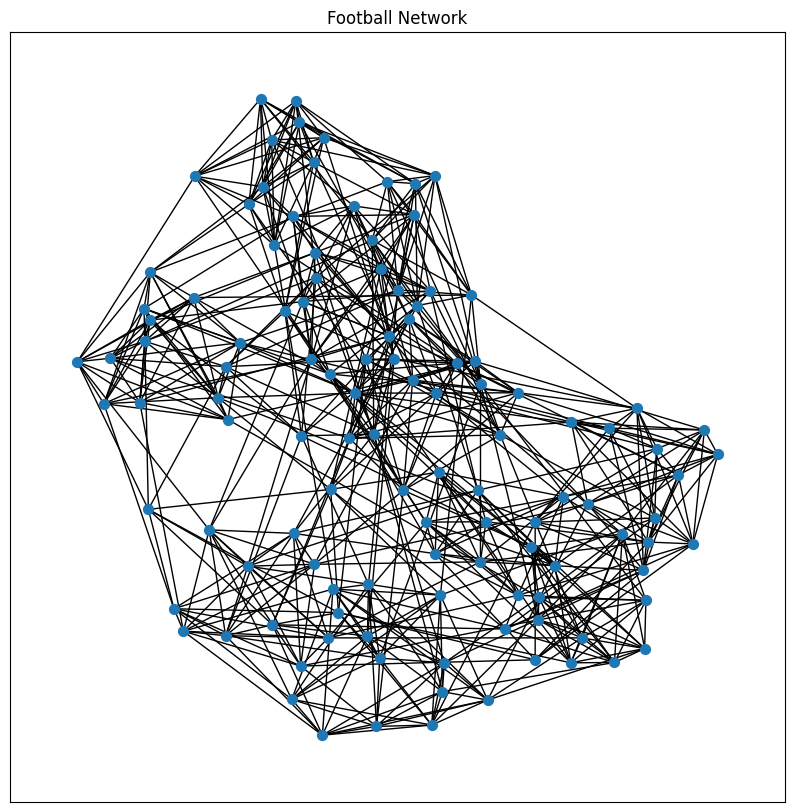

In [ ]:
plt.figure(figsize=(10, 10))
nx.draw_networkx(G, with_labels=False, node_size=50)
plt.title("Football Network")
plt.show()


Degré moyen : 10.66
Densité : 0.0935
Coefficient clustering moyen : 0.4032


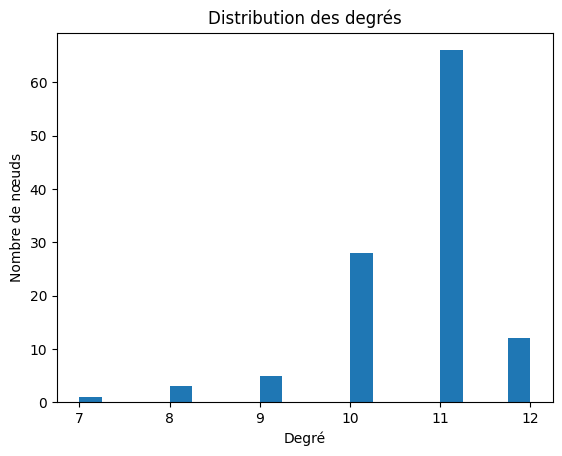

In [ ]:
#  Statistiques descriptives
degrees = [deg for node, deg in G.degree()]
print(f"Degré moyen : {np.mean(degrees):.2f}")
print(f"Densité : {nx.density(G):.4f}")
print(f"Coefficient clustering moyen : {nx.average_clustering(G):.4f}")

# Distribution des degrés
plt.hist(degrees, bins=20)
plt.title("Distribution des degrés")
plt.xlabel("Degré")
plt.ylabel("Nombre de nœuds")
plt.show()



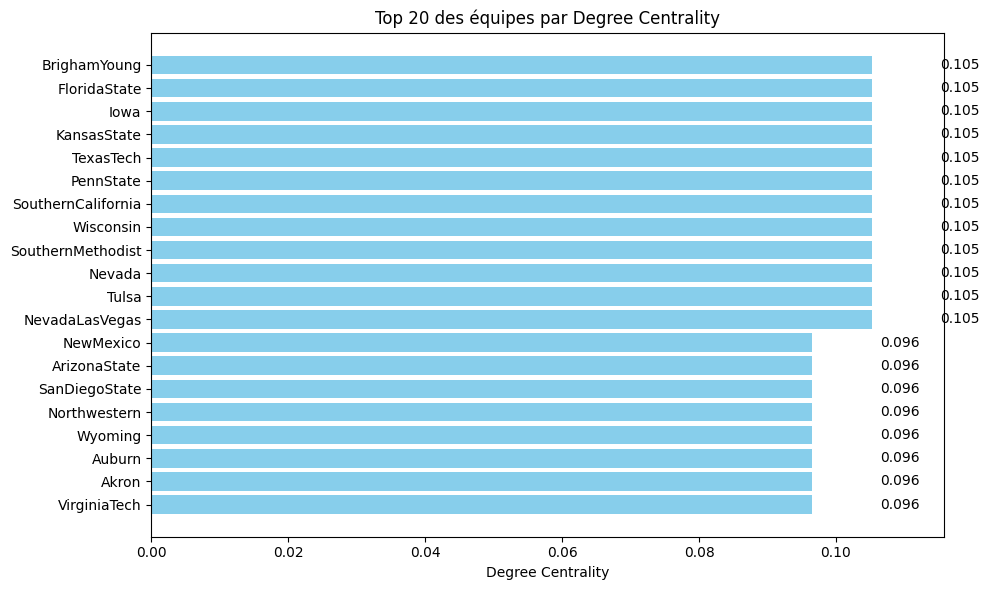

In [ ]:
import matplotlib.pyplot as plt

# Degree centrality (normalisée)
deg_cent = nx.degree_centrality(G)
top_deg = sorted(deg_cent.items(), key=lambda x: x[1], reverse=True)[:20]

# Préparer données pour le graphique
teams = [team for team, score in top_deg]
scores = [score for team, score in top_deg]

# Création du bar chart
plt.figure(figsize=(10,6))
bars = plt.barh(teams[::-1], scores[::-1], color='skyblue')  # inverser pour que le top soit en haut
plt.xlabel('Degree Centrality')
plt.title('Top 20 des équipes par Degree Centrality')
plt.xlim(0, max(scores)*1.1)

# Ajouter les valeurs sur chaque barre
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height()/2, f'{width:.3f}', va='center')

plt.tight_layout()
plt.show()


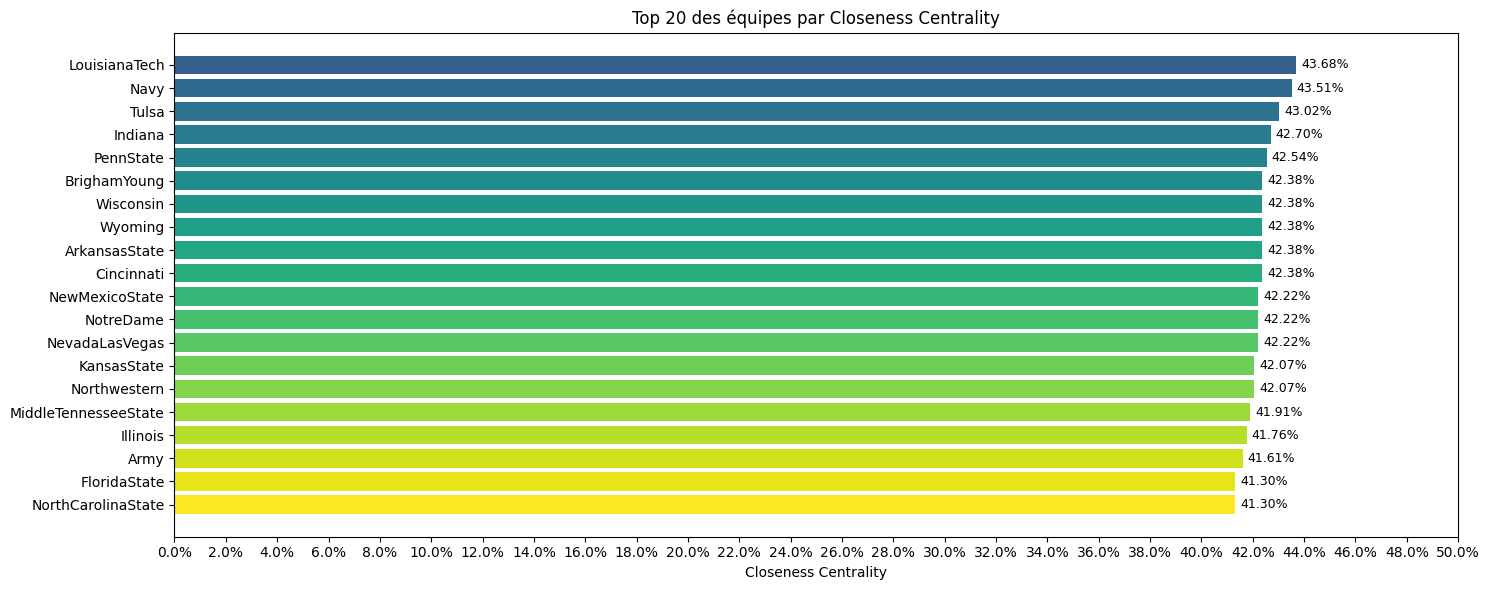

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Closeness centrality
close_cent = nx.closeness_centrality(G)
top_close = sorted(close_cent.items(), key=lambda x: x[1], reverse=True)[:20]

teams = [team for team, score in top_close]
scores = [score for team, score in top_close]

plt.figure(figsize=(15,6))

colors = plt.cm.viridis(np.linspace(0.3, 1, len(scores)))

bars = plt.barh(teams[::-1], scores[::-1], color=colors[::-1])
plt.xlabel('Closeness Centrality')
plt.title('Top 20 des équipes par Closeness Centrality')

max_score = max(scores)
plt.xlim(0, max_score * 1.1)

# Définir les ticks x à intervalles de 0.01 (1%) ou 0.02 selon la plage max_score
step = 0.01 if max_score < 0.1 else 0.02
ticks = np.arange(0, max_score * 1.1 + step, step)
ticks_labels = [f"{tick*100:.1f}%" for tick in ticks]

plt.xticks(ticks, ticks_labels)

# Afficher les valeurs à droite des barres
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.002, bar.get_y() + bar.get_height()/2, f'{width*100:.2f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()


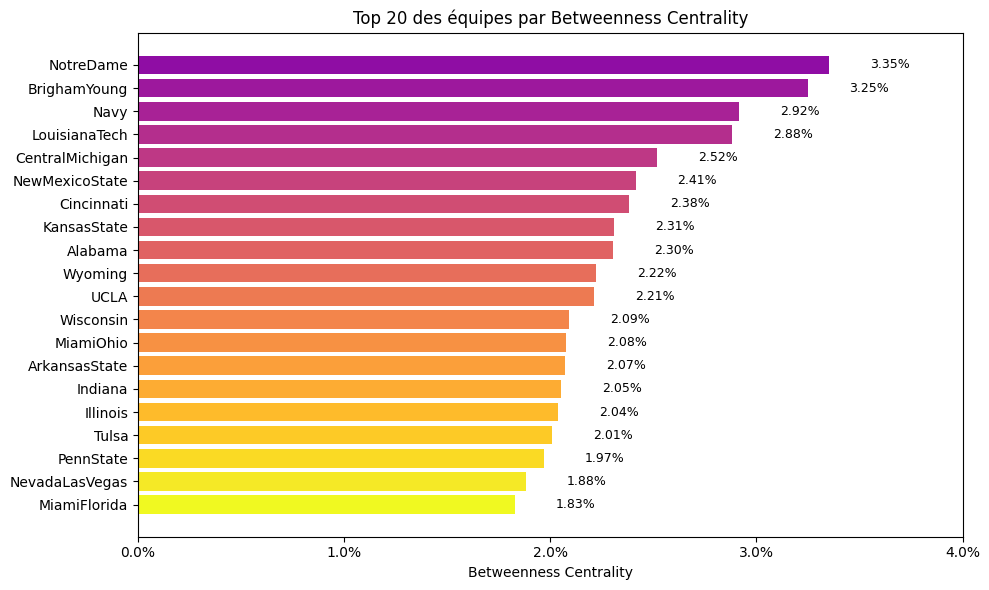

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Betweenness centrality
between_cent = nx.betweenness_centrality(G)
top_between = sorted(between_cent.items(), key=lambda x: x[1], reverse=True)[:20]

teams = [team for team, score in top_between]
scores = [score for team, score in top_between]

plt.figure(figsize=(10,6))

colors = plt.cm.plasma(np.linspace(0.3, 1, len(scores)))

bars = plt.barh(teams[::-1], scores[::-1], color=colors[::-1])
plt.xlabel('Betweenness Centrality')
plt.title('Top 20 des équipes par Betweenness Centrality')

max_score = max(scores)
plt.xlim(0, max_score * 1.1)

# Définir un pas d’intervalle pour les ticks (1% ou 2% selon la valeur max)
step = 0.01 if max_score < 0.1 else 0.02
ticks = np.arange(0, max_score * 1.1 + step, step)
ticks_labels = [f"{tick*100:.1f}%" for tick in ticks]

plt.xticks(ticks, ticks_labels)

# Affichage des valeurs sur chaque barre, légèrement à droite
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.002, bar.get_y() + bar.get_height()/2, f'{width*100:.2f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()



Calcul des longueurs de chemin les plus courts...


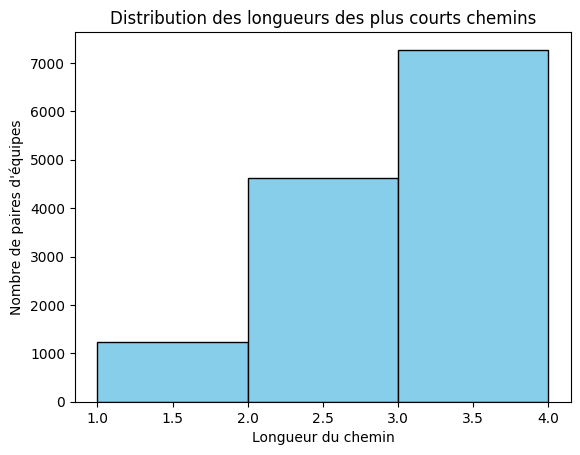

Longueur moyenne des plus courts chemins: 2.4864
Diamètre estimé (longueur max): 4


In [ ]:
#  Distribution des longueurs de chemin

# Calculer la longueur des plus courts chemins entre toutes les paires (peut être long sur gros graphes)
print("\nCalcul des longueurs de chemin les plus courts...")

path_lengths = dict(nx.all_pairs_shortest_path_length(G))

all_lengths = []
for source in path_lengths:
    lengths = path_lengths[source].values()
    all_lengths.extend(lengths)

# Distribution
plt.hist(all_lengths, bins=range(1, max(all_lengths)+1), color='skyblue', edgecolor='black')
plt.title("Distribution des longueurs des plus courts chemins")
plt.xlabel("Longueur du chemin")
plt.ylabel("Nombre de paires d'équipes")
plt.show()

mean_path_length = np.mean(all_lengths)
print(f"Longueur moyenne des plus courts chemins: {mean_path_length:.4f}")

# Vérification propriété "small-world" simple
print(f"Diamètre estimé (longueur max): {max(all_lengths)}")


Nombre de communautés détectées par Louvain : 10
Modularité Louvain : 0.6044


<ipython-input-46-b76728b25320>:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis', int(size))


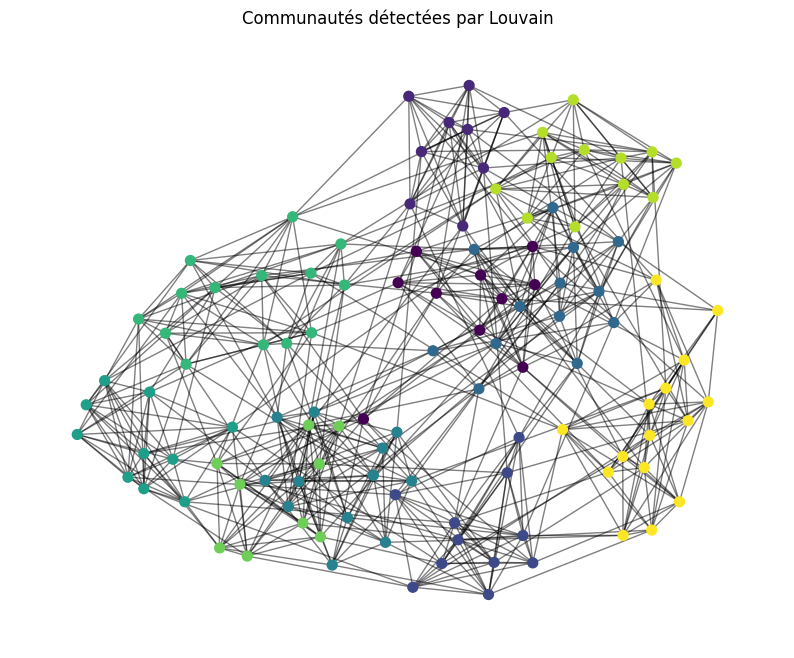

In [ ]:
#  Détection de communautés

## 3Louvain
partition_louvain = community_louvain.best_partition(G)
num_communities_louvain = len(set(partition_louvain.values()))
print(f"Nombre de communautés détectées par Louvain : {num_communities_louvain}")

modularity_louvain = community_louvain.modularity(partition_louvain, G)
print(f"Modularité Louvain : {modularity_louvain:.4f}")

# Fonction pour dessiner graph avec communautés
def draw_communities(graph, partition, title):
    size = float(len(set(partition.values())))
    pos = nx.spring_layout(graph, seed=42)
    colors = [partition[node] for node in graph.nodes()]
    cmap = plt.cm.get_cmap('viridis', int(size))

    plt.figure(figsize=(10, 8))
    nx.draw_networkx_nodes(graph, pos, node_size=50, cmap=cmap, node_color=colors)
    nx.draw_networkx_edges(graph, pos, alpha=0.5)
    plt.title(title)
    plt.axis('off')
    plt.show()

draw_communities(G, partition_louvain, "Communautés détectées par Louvain")


Nombre de communautés détectées par Girvan-Newman (choix): 10
Modularité Girvan-Newman : 0.5996


<ipython-input-46-b76728b25320>:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis', int(size))


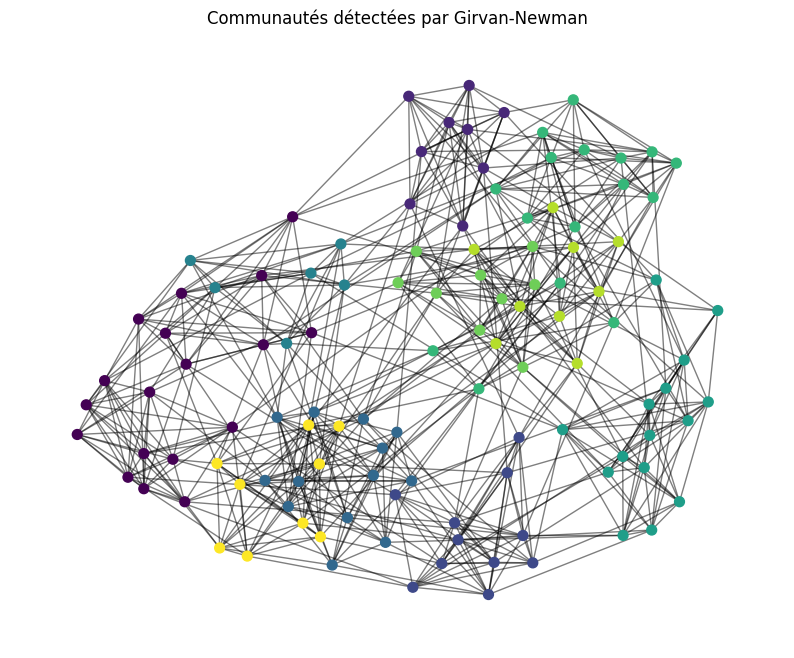

In [ ]:

##  Girvan-Newman
# On choisit un nombre fixe de communautés, par exemple 10

def girvan_newman_communities(G, k):
    comp = girvan_newman(G)
    limited = ()
    for communities in comp:
        limited = communities
        if len(limited) >= k:
            break
    return [list(c) for c in limited]

communities_gn = girvan_newman_communities(G, 10)
print(f"Nombre de communautés détectées par Girvan-Newman (choix): {len(communities_gn)}")

# Créer une partition dict {node: community}
partition_gn = {}
for i, com in enumerate(communities_gn):
    for node in com:
        partition_gn[node] = i

modularity_gn = community_louvain.modularity(partition_gn, G)
print(f"Modularité Girvan-Newman : {modularity_gn:.4f}")

draw_communities(G, partition_gn, "Communautés détectées par Girvan-Newman")


In [ ]:
!pip install node2vec
# Installer ou mettre à jour les dépendances nécessaires
# Désinstaller numpy et scipy pour éviter les conflits de version
!pip uninstall -y numpy scipy

# Installer des versions spécifiques connues pour être compatibles
# Vous pouvez ajuster ces versions si nécessaire, mais c'est un bon point de départ
!pip install numpy==1.25.2 scipy==1.11.2 gensim==4.3.2

# Installer node2vec qui dépend de gensim
!pip install node2vec

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: scipy 1.13.1
Uninstalling scipy-1.13.1:
  Successfully uninstalled scipy-1.13.1
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 53.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 42.2 MB/s eta 0:00:00
  Attempting uninstall: gensim
    Found existing installation: gensim 4.3.3
    Uninstalling gensim-4.3.3:
      Successfully uninstalled gensim-4.3.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 1.25.2 which is incompatible.
blosc2 3.3.2 requires numpy>=1.26, but y

Computing transition probabilities:   0%|          | 0/115 [00:00<?, ?it/s]

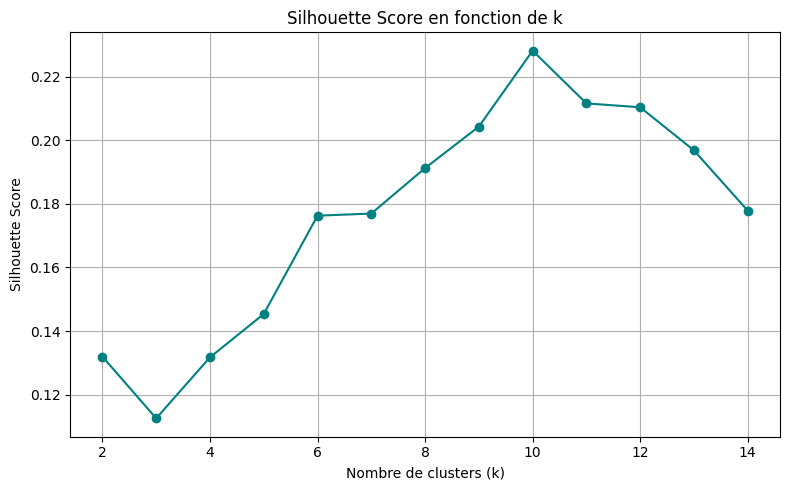

Meilleur k choisi selon Silhouette Score : 10
Modularité Node2Vec + KMeans (k=10) : 0.5961


<ipython-input-46-b76728b25320>:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis', int(size))


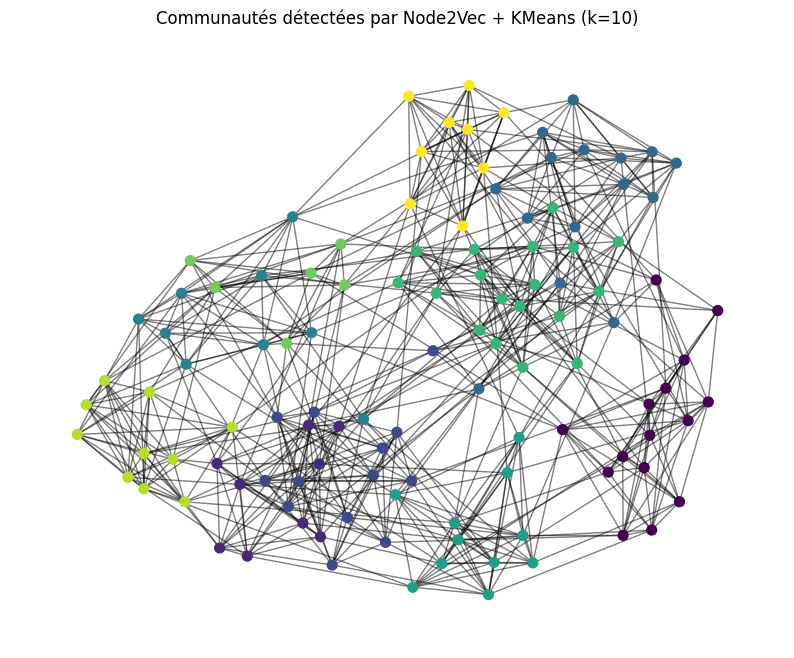

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np
from node2vec import Node2Vec

# Générer les embeddings Node2Vec
node2vec = Node2Vec(G, dimensions=64, walk_length=30, num_walks=200, workers=4, seed=42)
model = node2vec.fit(window=10, min_count=1)

# Extraire vecteurs des nœuds
nodes = list(G.nodes())
embeddings = np.array([model.wv[str(node)] for node in nodes])

# Trouver le meilleur k avec silhouette score
silhouette_scores = []
ks = range(2, 15)  # Tester k de 2 à 14

for k in ks:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(embeddings)
    score = silhouette_score(embeddings, labels)
    silhouette_scores.append(score)

# Visualiser les scores de silhouette
plt.figure(figsize=(8, 5))
plt.plot(ks, silhouette_scores, marker='o', color='teal')
plt.title("Silhouette Score en fonction de k")
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.tight_layout()
plt.show()

# Choix du meilleur k (k avec le score silhouette max)
best_k = ks[np.argmax(silhouette_scores)]
print(f"Meilleur k choisi selon Silhouette Score : {best_k}")

# Refaire le clustering avec le meilleur k
kmeans = KMeans(n_clusters=best_k, random_state=42)
labels = kmeans.fit_predict(embeddings)
partition_node2vec = {node: label for node, label in zip(nodes, labels)}

# Calcul de la modularité
modularity_node2vec = community_louvain.modularity(partition_node2vec, G)
print(f"Modularité Node2Vec + KMeans (k={best_k}) : {modularity_node2vec:.4f}")

# Dessin des communautés
draw_communities(G, partition_node2vec, f"Communautés détectées par Node2Vec + KMeans (k={best_k})")


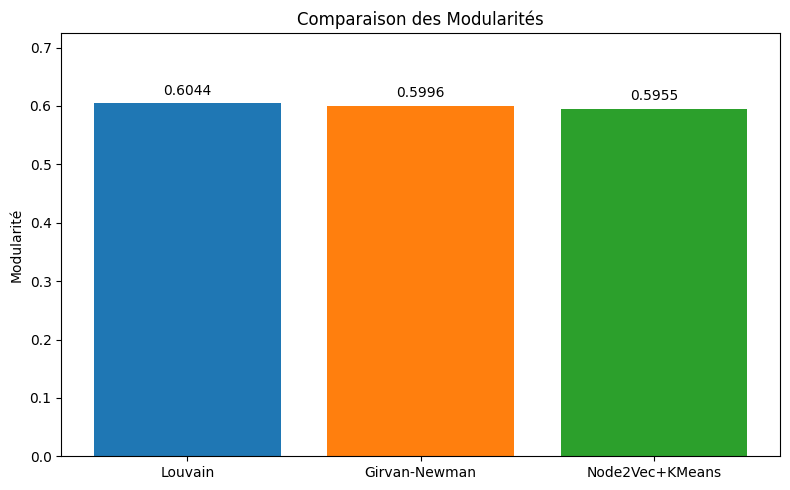

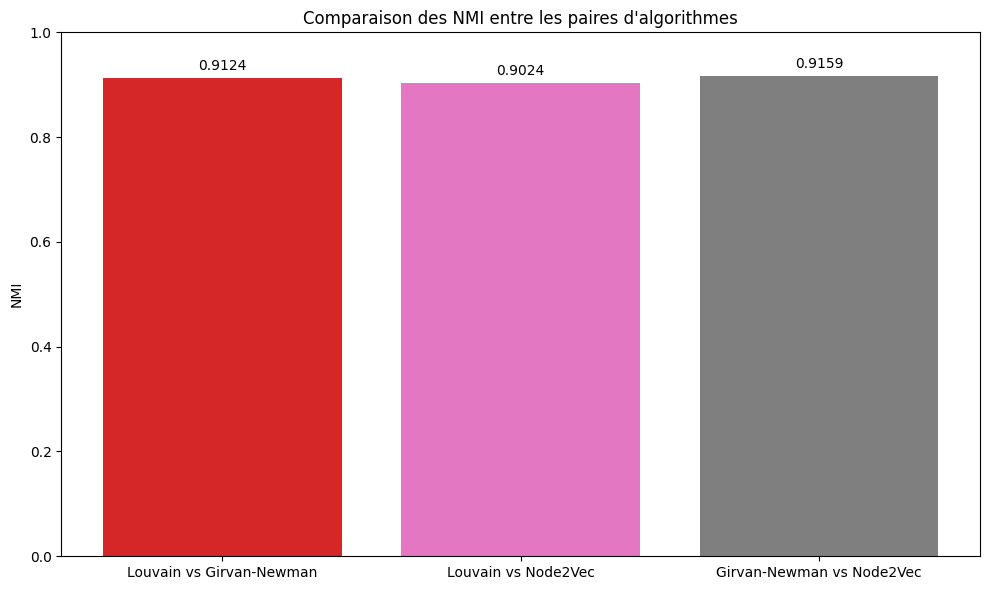


--- Métriques Résumé ---
Modularité Louvain: 0.6044
Modularité Girvan-Newman: 0.5996
Modularité Node2Vec+KMeans: 0.5955
--------------------
NMI Louvain vs Girvan-Newman: 0.9124
NMI Louvain vs Node2Vec: 0.9024
NMI Girvan-Newman vs Node2Vec: 0.9159
--------------------


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import normalized_mutual_info_score, silhouette_score
from collections import Counter

# Récupérer la liste des nœuds
nodes = list(G.nodes())

# Listes de labels pour chaque méthode
labels_louvain = [partition_louvain[node] for node in nodes]
labels_gn = [partition_gn[node] for node in nodes]
labels_node2vec = labels  # Déjà dans le bon ordre


# NMI (Normalized Mutual Information) entre chaque paire
nmi_louvain_gn = normalized_mutual_info_score(labels_louvain, labels_gn)
nmi_louvain_node2vec = normalized_mutual_info_score(labels_louvain, labels_node2vec)
nmi_gn_node2vec = normalized_mutual_info_score(labels_gn, labels_node2vec)

# ---- MODULARITÉ ----
modularities = [modularity_louvain, modularity_gn, modularity_node2vec]
algos = ["Louvain", "Girvan-Newman", "Node2Vec+KMeans"]

plt.figure(figsize=(8, 5))
plt.bar(algos, modularities, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.ylabel("Modularité")
plt.title("Comparaison des Modularités")
plt.ylim(0, max(modularities)*1.2)
for i, val in enumerate(modularities):
    plt.text(i, val + 0.01, f"{val:.4f}", ha='center', va='bottom')
plt.tight_layout()
plt.show()

# ---- NMI ----
nmi_labels = ["Louvain vs Girvan-Newman", "Louvain vs Node2Vec", "Girvan-Newman vs Node2Vec"]
nmi_values = [nmi_louvain_gn, nmi_louvain_node2vec, nmi_gn_node2vec]

plt.figure(figsize=(10, 6))
plt.bar(nmi_labels, nmi_values, color=['#d62728', '#e377c2', '#7f7f7f'])
plt.ylabel("NMI")
plt.title("Comparaison des NMI entre les paires d'algorithmes")
plt.ylim(0, 1)
for i, val in enumerate(nmi_values):
    plt.text(i, val + 0.01, f"{val:.4f}", ha='center', va='bottom')
plt.tight_layout()
plt.show()



print("\n--- Métriques Résumé ---")
print(f"Modularité Louvain: {modularity_louvain:.4f}")
print(f"Modularité Girvan-Newman: {modularity_gn:.4f}")
print(f"Modularité Node2Vec+KMeans: {modularity_node2vec:.4f}")
print("-" * 20)
print(f"NMI Louvain vs Girvan-Newman: {nmi_louvain_gn:.4f}")
print(f"NMI Louvain vs Node2Vec: {nmi_louvain_node2vec:.4f}")
print(f"NMI Girvan-Newman vs Node2Vec: {nmi_gn_node2vec:.4f}")
print("-" * 20)

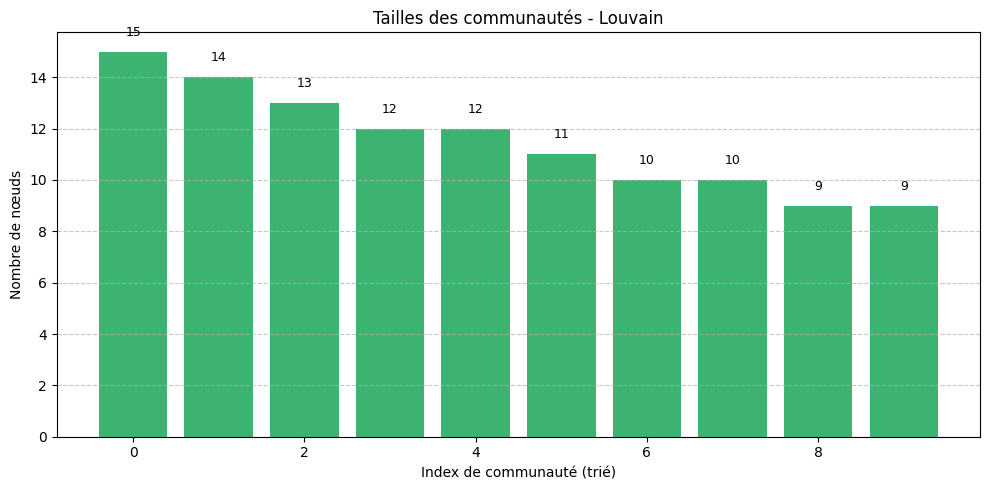

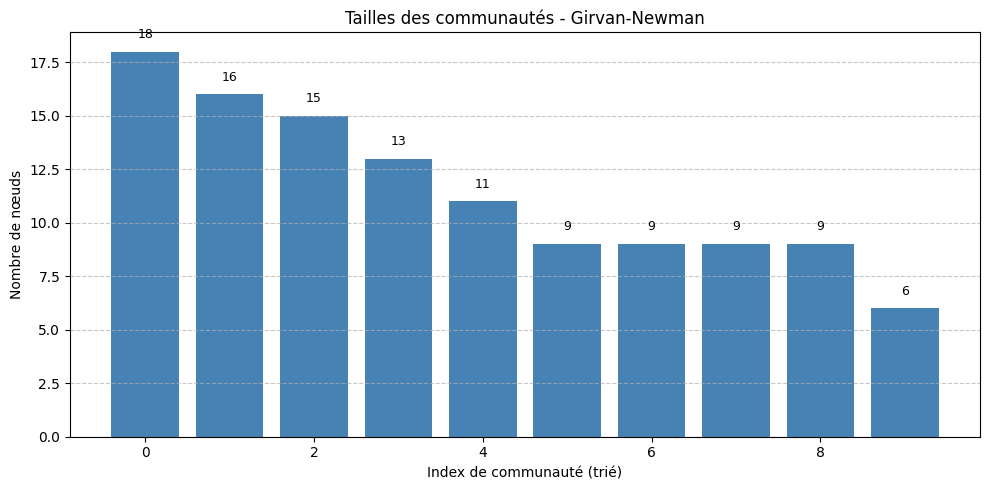

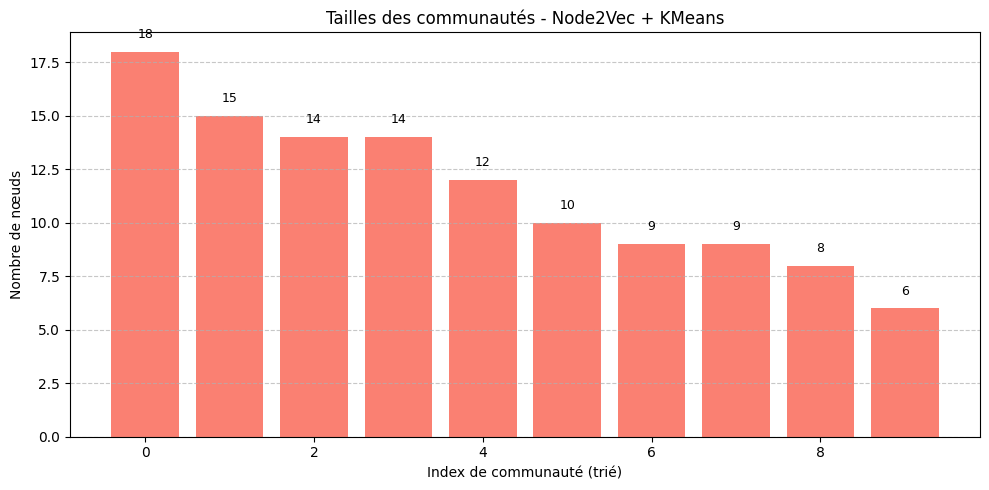

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

def plot_community_sizes(sizes, method_name, color):
    if isinstance(sizes, dict):  # Pour Louvain et Node2Vec+KMeans (Counter)
        sizes = sorted(sizes.values(), reverse=True)
    elif isinstance(sizes, list):  # Pour Girvan-Newman (list of community sizes)
        sizes = sorted(sizes, reverse=True)

    plt.figure(figsize=(10, 5))
    bars = plt.bar(range(len(sizes)), sizes, color=color)
    plt.title(f'Tailles des communautés - {method_name}')
    plt.xlabel('Index de communauté (trié)')
    plt.ylabel('Nombre de nœuds')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Afficher la taille exacte au-dessus de chaque barre si < 15 communautés
    if len(sizes) <= 15:
        for i, size in enumerate(sizes):
            plt.text(i, size + 0.5, str(size), ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

# 1. Louvain
plot_community_sizes(Counter(partition_louvain.values()), "Louvain", "mediumseagreen")

# 2. Girvan-Newman
plot_community_sizes([len(c) for c in communities_gn], "Girvan-Newman", "steelblue")

# 3. Node2Vec + KMeans
plot_community_sizes(Counter(labels), "Node2Vec + KMeans", "salmon")


In [ ]:
# 3. Étude des ponts et arêtes inter-communautés
# On récupère les communautés par Louvain (exemple)
partition = community_louvain.best_partition(G)

# Fonction pour savoir si une arête est inter-communautés
def is_inter_community(u, v, partition):
    return partition[u] != partition[v]

edges_inter = [e for e in G.edges() if is_inter_community(e[0], e[1], partition)]
edges_intra = [e for e in G.edges() if not is_inter_community(e[0], e[1], partition)]

print(f"\nNombre d'arêtes totales : {G.number_of_edges()}")
print(f"Nombre d'arêtes inter-communautés : {len(edges_inter)}")
print(f"Nombre d'arêtes intra-communautés : {len(edges_intra)}")
print(f"Proportion d'arêtes inter-communautés : {len(edges_inter) / G.number_of_edges():.4f}")




Nombre d'arêtes totales : 613
Nombre d'arêtes inter-communautés : 179
Nombre d'arêtes intra-communautés : 434
Proportion d'arêtes inter-communautés : 0.2920


<ipython-input-45-f0c4b93c3714>:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', max(partition.values()) + 1)


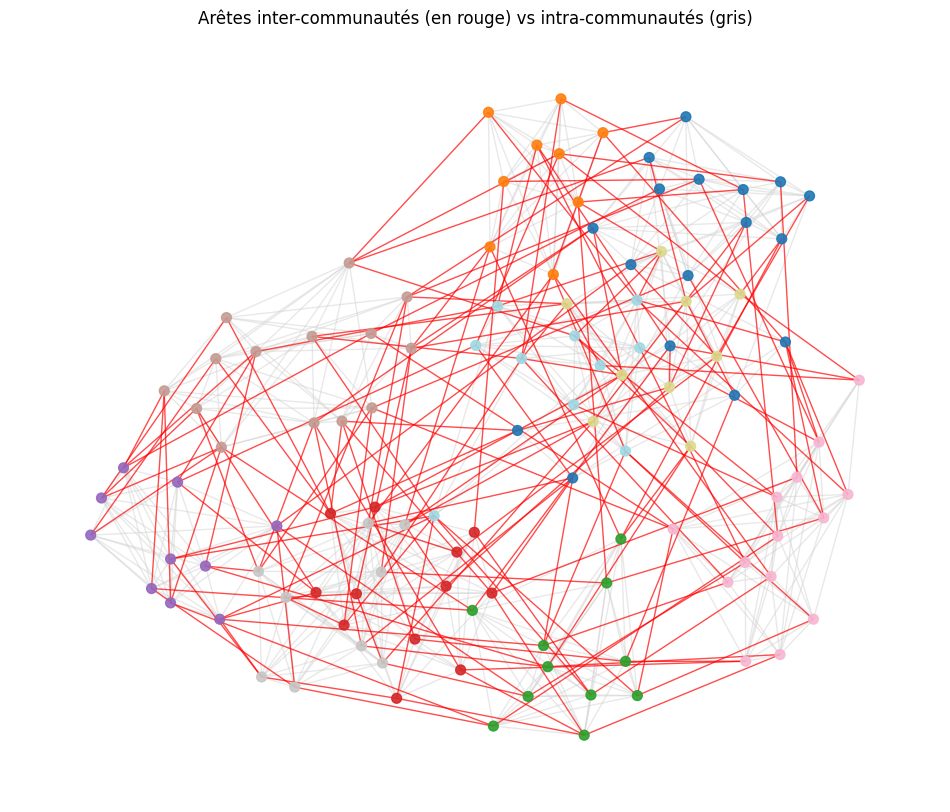

In [ ]:
# Visualisation des arêtes inter-communautés sur le graphe
pos = nx.spring_layout(G, seed=42)
plt.figure(figsize=(12, 10))

# Noeuds colorés par communauté
cmap = plt.cm.get_cmap('tab20', max(partition.values()) + 1)
node_colors = [cmap(partition[node]) for node in G.nodes()]
nx.draw_networkx_nodes(G, pos, node_size=50, node_color=node_colors, alpha=0.9)

# Arêtes intra-communautés en gris clair
nx.draw_networkx_edges(G, pos, edgelist=edges_intra, edge_color='lightgrey', alpha=0.5)

# Arêtes inter-communautés en rouge
nx.draw_networkx_edges(G, pos, edgelist=edges_inter, edge_color='red', alpha=0.7, width=1)

plt.title("Arêtes inter-communautés (en rouge) vs intra-communautés (gris)")
plt.axis('off')
plt.show()

In [ ]:
import os
import zipfile

# prompt: /content/unsupervised_AKHAIL_SANOGO.rar decompresser ce fichier et le compresserven .zip

# Spécifiez le chemin du fichier RAR à décompresser
rar_file_path = '/content/unsupervised_AKHAIL_SANOGO.rar'

# Spécifiez le répertoire où vous voulez extraire les fichiers RAR
extract_dir_rar = '/content/unsupervised_AKHAIL_SANOGO_extracted/'

# Créez le répertoire d'extraction s'il n'existe pas
os.makedirs(extract_dir_rar, exist_ok=True)

# Decompressez le fichier RAR
# Note: Pour décompresser des fichiers .rar en Python sans librairies externes
# (qui ne sont pas toujours simples à installer sur Colab), on utilise souvent
# la commande unrar du système. Il faut s'assurer qu'elle est disponible.
# Colab l'a généralement préinstallée.
try:
    # La commande 'unrar x' extrait avec les chemins complets, 'e' sans chemins
    # On utilise 'x' pour recréer la structure de dossiers si nécessaire
    !unrar x "$rar_file_path" "$extract_dir_rar"
    print(f"Fichier RAR décompressé vers : {extract_dir_rar}")

except Exception as e:
    print(f"Une erreur s'est produite lors de la décompression du fichier RAR : {e}")
    print("Veuillez vérifier si unrar est installé et si le chemin du fichier RAR est correct.")
    # Si unrar n'est pas installé, vous pourriez tenter de l'installer (peut nécessiter sudo, non possible en Colab)
    # !apt-get update
    # !apt-get install unrar-free

# Spécifiez le chemin où vous voulez créer le fichier ZIP compressé
zip_file_path_output = '/content/unsupervised_AKHAIL_SANOGO.zip'

# Compressez le contenu du répertoire extrait en un fichier ZIP
try:
    # Ouvrir le fichier zip en mode écriture ('w')
    with zipfile.ZipFile(zip_file_path_output, 'w', zipfile.ZIP_DEFLATED) as zipf:
        # Parcourir tous les fichiers et dossiers dans le répertoire extrait
        for root, dirs, files in os.walk(extract_dir_rar):
            for file in files:
                # Créer le chemin complet du fichier
                file_path = os.path.join(root, file)
                # Calculer le chemin relatif pour le zip (enlève le répertoire d'extraction initial)
                # Ceci évite d'avoir /content/unsupervised_AKHAIL_SANOGO_extracted/... dans le zip
                relative_path = os.path.relpath(file_path, extract_dir_rar)
                # Ajouter le fichier au zip
                zipf.write(file_path, relative_path)

    print(f"Contenu compressé en ZIP vers : {zip_file_path_output}")

except Exception as e:
    print(f"Une erreur s'est produite lors de la compression en ZIP : {e}")

# Vous pouvez maintenant vérifier le contenu du répertoire extrait et le fichier zip créé
!ls -R /content/unsupervised_AKHAIL_SANOGO_extracted/
!ls -lh /content/unsupervised_AKHAIL_SANOGO.zip


Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
basic.cpython-312.pyc	 history.cpython-312.pyc    pylab.cpython-312.pyc
code.cpython-312.pyc	 __init__.cpython-312.pyc   script.cpython-312.pyc
config.cpython-312.pyc	 logging.cpython-312.pyc
display.cpython-312.pyc  namespace.cpython-312.pyc

/content/unsupervised_AKHAIL_SANOGO_extracted/unsupervised_AKHAIL_SANOGO/Interface_avec_streamlit/venv/Lib/site-packages/IPython/core/profile:
README_STARTUP

/content/unsupervised_AKHAIL_SANOGO_extracted/unsupervised_AKHAIL_SANOGO/Interface_avec_streamlit/venv/Lib/site-packages/IPython/core/__pycache__:
alias.cpython-312.pyc		   hooks.cpython-312.pyc
application.cpython-312.pyc	   __init__.cpython-312.pyc
async_helpers.cpython-312.pyc	   inputtransformer2.cpython-312.pyc
autocall.cpython-312.pyc	   interactiveshell.cpython-312.pyc
builtin_trap.cpython-312.pyc	   latex_symbols.cpython-312.pyc
compilerop.cpython-312.pyc	   logger.cpython-312.pyc
completer.cpython-312.pyc